<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/01_EDA_PHM18_etching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive 불러오기

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


train 폴더의 '01_M01_DC_train.csv' 파일 열어보기

In [4]:
import pandas as pd

path_train = '/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv' #MyDrive #/

df_train = pd.read_csv(path_train)
print("행, 렬:", df_train.shape)
df_train.head()

행, 렬: (3124704, 24)


,time,Tool,stage,Lot,runnum,recipe,recipe_step,IONGAUGEPRESSURE,ETCHBEAMVOLTAGE,ETCHBEAMCURRENT,...,ETCHGASCHANNEL1READBACK,ETCHPBNGASREADBACK,FIXTURETILTANGLE,ROTATIONSPEED,ACTUALROTATIONANGLE,FIXTURESHUTTERPOSITION,ETCHSOURCEUSAGE,ETCHAUXSOURCETIMER,ETCHAUX2SOURCETIMER,ACTUALSTEPDURATION
0,3283106,01M01,1,589,10511625,1,5.0,0.745235,1.085043,-1.151842,...,0.744638,0.727147,1.170894,-0.203892,-0.152495,0.0,-0.071733,-0.257798,0.862781,-0.200587
1,3283110,01M01,1,589,10511625,1,5.0,-0.037024,-0.932286,-1.152112,...,-1.312143,-1.405385,1.170894,-0.203892,-0.152495,0.0,-0.071733,-0.257798,0.862781,-0.200587
2,3283114,01M01,1,589,10511625,1,5.0,-0.507875,-1.106610,-1.151909,...,-1.312143,-1.405385,1.170894,-0.203892,-0.152495,0.0,-0.071733,-0.257798,0.862781,-0.200587
3,3283118,01M01,1,589,10511625,1,5.0,-0.793893,-1.128402,-1.151977,...,-1.312143,-1.405385,1.170894,-0.203892,-0.152495,0.0,-0.071733,-0.257798,0.862781,-0.200587
4,3283122,01M01,1,589,10511625,1,5.0,-0.977717,-1.128402,-1.151706,...,-1.312143,-1.405385,1.170894,-0.203892,-0.152495,0.0,-0.071733,-0.257798,0.862781,-0.200587


행 항목 전체 확인

In [5]:
print(df_train.columns.tolist())

['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION']


train_ttf 폴더의 '01_M01_DC_train.csv'파일 열어보기

In [7]:
path_ttf = '/content/drive/MyDrive/phm18/train_ttf/01_M01_DC_train.csv'

df_ttf = pd.read_csv(path_ttf)
print("행, 렬:", df_ttf.shape)
print(df_ttf.columns.tolist())
df_ttf.head()

행, 렬: (3124704, 4)
['time', 'TTF_FlowCool Pressure Dropped Below Limit', 'TTF_Flowcool Pressure Too High Check Flowcool Pump', 'TTF_Flowcool leak']


,time,TTF_FlowCool Pressure Dropped Below Limit,TTF_Flowcool Pressure Too High Check Flowcool Pump,TTF_Flowcool leak
0,3283106,3250078.0,9355132.0,16891832.0
1,3283110,3250074.0,9355128.0,16891828.0
2,3283114,3250070.0,9355124.0,16891824.0
3,3283118,3250066.0,9355120.0,16891820.0
4,3283122,3250062.0,9355116.0,16891816.0


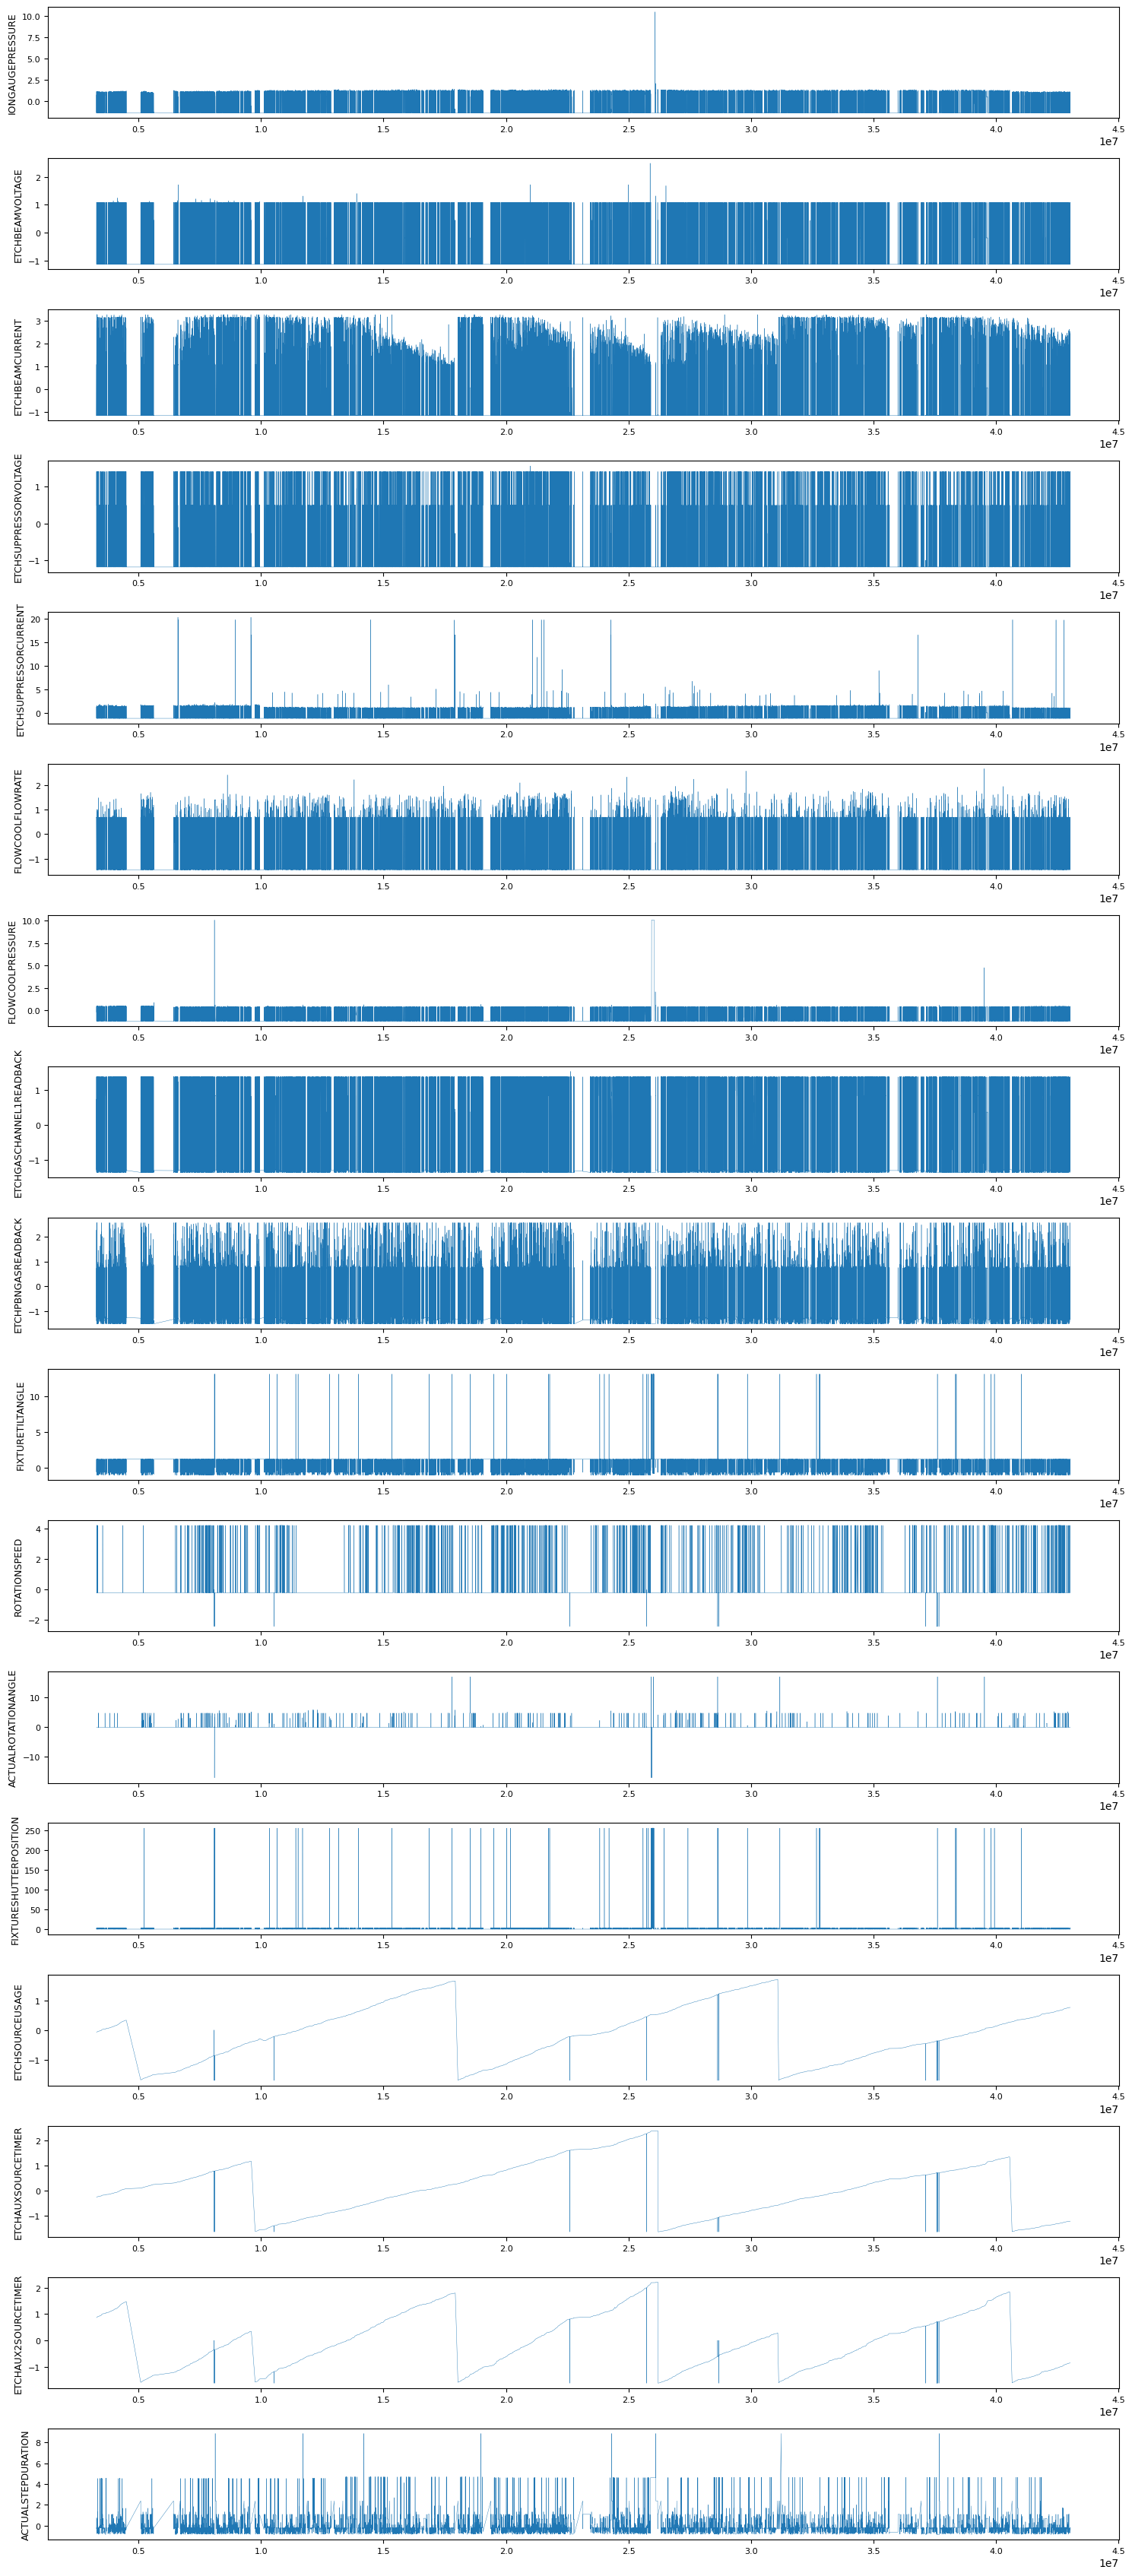

In [8]:
df = df_train.merge(df_ttf, on='time')

sensor_cols = [ 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT',
               'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE',
                'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK',
                'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE',
                'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER',
                'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION' ]

import matplotlib.pyplot as plt

fig, axes = plt.subplots( len(sensor_cols), 1, figsize=(15, len(sensor_cols)*2) )

for i, col in enumerate(sensor_cols):
  axes[i].plot( df["time"], df[col], linewidth=0.3 )
  axes[i].set_ylabel(col, fontsize=9)
  axes[i].tick_params(labelsize=8) # 축 눈금(tick) 스타일을 설정하는 함수

plt.tight_layout()
plt.show()


FLOWCOOLPRESSURE 살펴보기

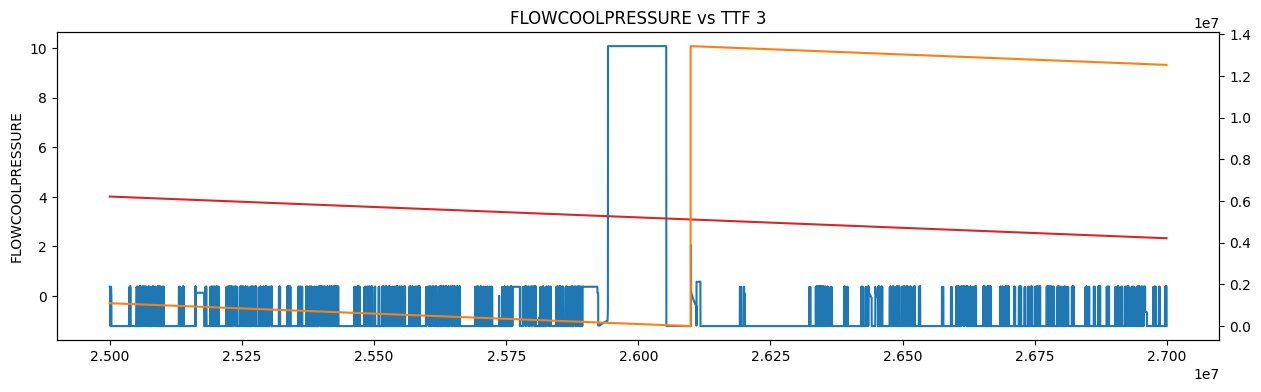

In [16]:
window = df[ (df["time"] > 2.5e7) & (df["time"] < 2.7e7) ]

df = df.rename( columns={
    'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
    'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
    'TTF_Flowcool leak': 'TTF_leak'
    }) # comma

fig, ax1 = plt.subplots(figsize=(15, 4)) # fig: 전체 도화지
# ax1: 그래프가 하나일 때
# axes: 그래프를 여러 개 나누어 그릴 때
ax1.plot( window["time"], window["FLOWCOOLPRESSURE"], color='tab:blue' )
ax1.set_ylabel('FLOWCOOLPRESSURE')

ax2 = ax1.twinx() # twinx(): x축은 공유하되 y축은 따로 만들기
ax2.plot( window["time"], window["TTF_pressure_drop"], color='tab:red' )
ax2.plot( window["time"], window["TTF_pressure_high"], color='tab:orange')
ax2.plot( window["time"], window["TTF_leak"], color='tab:green')

plt.title("FLOWCOOLPRESSURE vs TTF 3")
plt.show()

'TTF_leak' 데이터가 안 그려지는 이유 찾아보기

In [23]:
print(df.columns.tolist()) # 이름은 제대로 바뀜

print(window["TTF_leak"].describe()) # TTF_leak의 최댓값, 최소값, 평균 등
print(window["TTF_leak"].isna().sum()) # 결측값이 몇 개인지


['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: TTF_leak, dtype: float64
236828


센서 vs TTF 상관관계 계산

In [27]:
print(df.columns.tolist())
ttf_cols = [ 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak' ]

corr = df[sensor_cols + ttf_cols].corr()
corr_ttf = corr.loc[ sensor_cols, ttf_cols ]
print(corr_ttf)

['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']
                         TTF_pressure_drop  TTF_pressure_high  TTF_leak
IONGAUGEPRESSURE                  0.010567           0.008017 -0.001035
ETCHBEAMVOLTAGE                   0.013649           0.011060 -0.003264
ETCHBEAMCURRENT                   0.006055           0.007851  0.016645
ETCHSUPPRESSORVOLTAGE            -0.003918           0.013824  0.035809
ETCHSUPPRESSORCURRENT            -0.015696           0.026035  0.090449
FLOWCOOLFLOWRATE                  0.008946           0.022253  0.002905
FLOWC

In [ ]:
센서 vs TTF 상관관계를 히트맵으로 표현

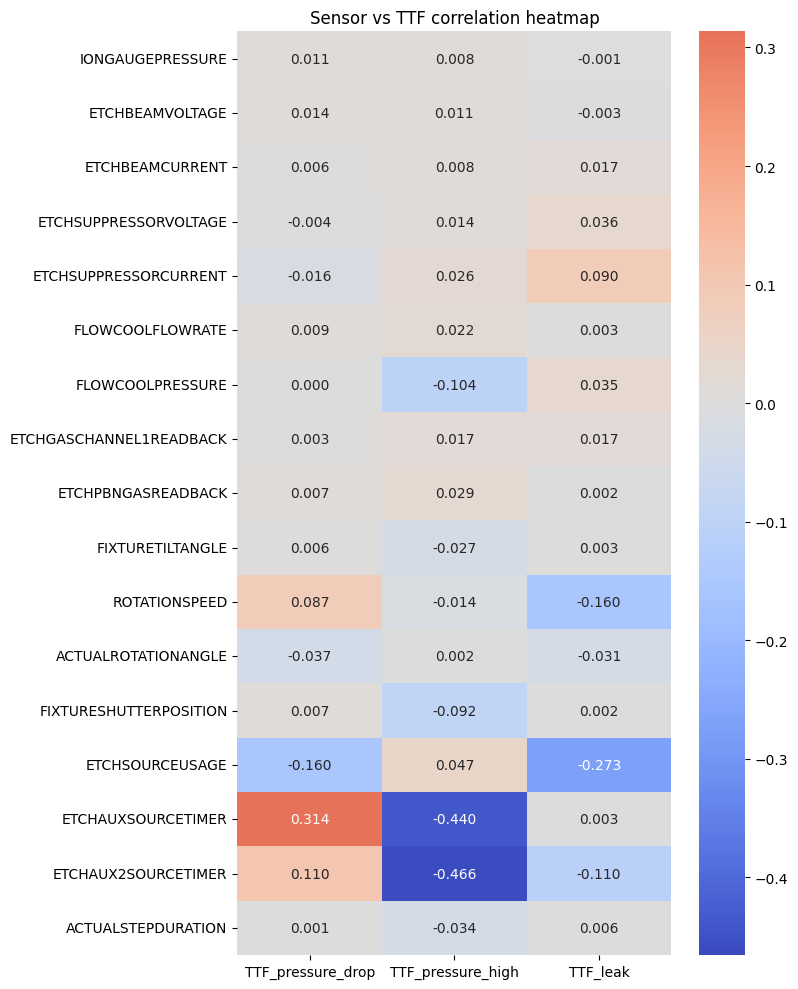

In [35]:
import seaborn as sns

plt.figure(figsize=(8, 10))
sns.heatmap(corr_ttf,
            annot = True,      # 각 칸에 숫자 표시
            fmt = '.3f',       # 소수점 두 자리
            cmap = 'coolwarm', # 빨강-파랑
            center = 0)        # 0을 중심으로 색상 분기

plt.title("Sensor vs TTF correlation heatmap")
plt.tight_layout() # 그래프가 겹치지 않게 깔끔하게
plt.show()